# Checking QPSK modulation

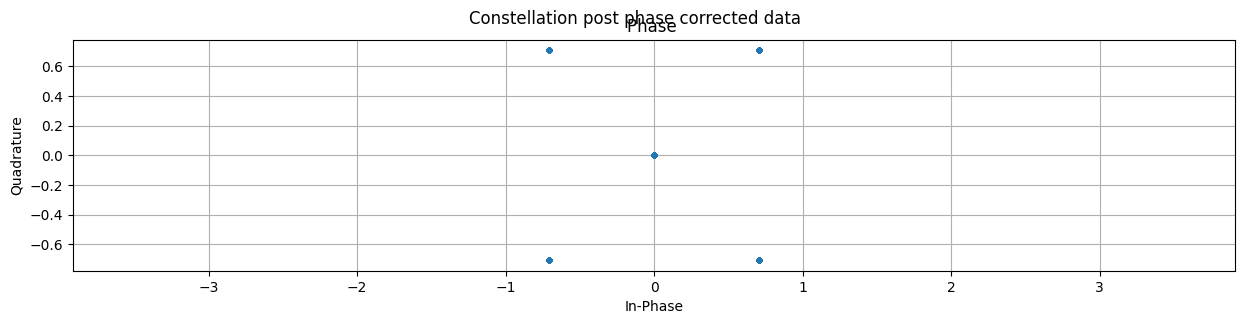

In [1]:
#file last updated 11/16/2025
import numpy as np
import matplotlib.pyplot as plt
import math
data = np.loadtxt("repo/src/output/QPSK_mod.dat")

complex_data = data[:,0] + 1j * data[:,1]

downsampled = complex_data


fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=6, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
#plt.xlim(-1, 1)
#plt.ylim(-1, 1)
plt.show()




# seeing what the energy detector finds in QPSK

901


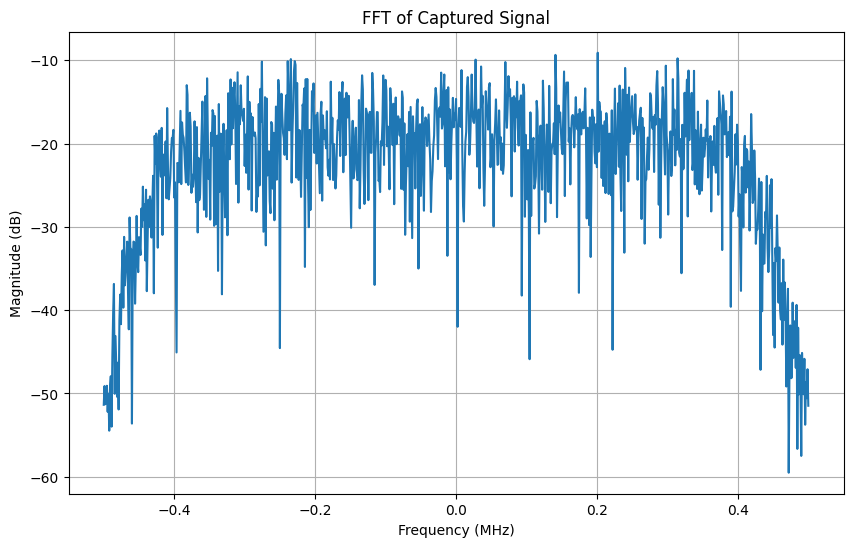

0j
3.121389663865806
0.0017341053688143366


In [2]:
#file last updated 11/16/2025
import numpy as np
import matplotlib.pyplot as plt
import math
data = np.loadtxt("repo/src/output/QPSK_energy_detected.dat")

complex_data = data[:,0] + 1j * data[:,1]

downsampled = complex_data


fs = (1e6)


# Compute FFT
N = len(complex_data)
print(N)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


total = 0
for i in complex_data:
    total = total + abs(i)
print(complex_data[0])
print(total)
print(total/2 / 900)

# Seeing what the correction does to out QPSK


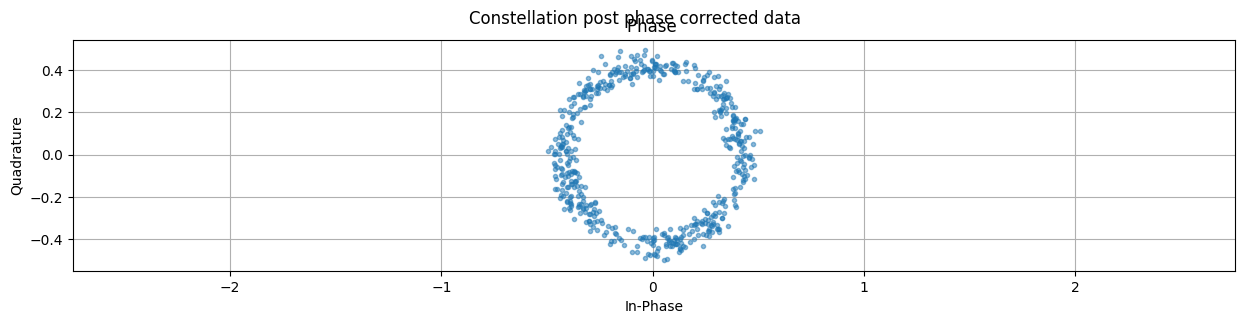

In [3]:
#file last updated 11/16/2025
import numpy as np
import matplotlib.pyplot as plt
import math
data = np.loadtxt("repo/src/output/QPSK_after_correction.dat")

complex_data = data[:,0] + 1j * data[:,1]

downsampled = complex_data


fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=6, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
#plt.xlim(-1, 1)
#plt.ylim(-1, 1)
plt.show()




# QPSK Time domain of packet before demoulation

534


<IPython.core.display.Javascript object>


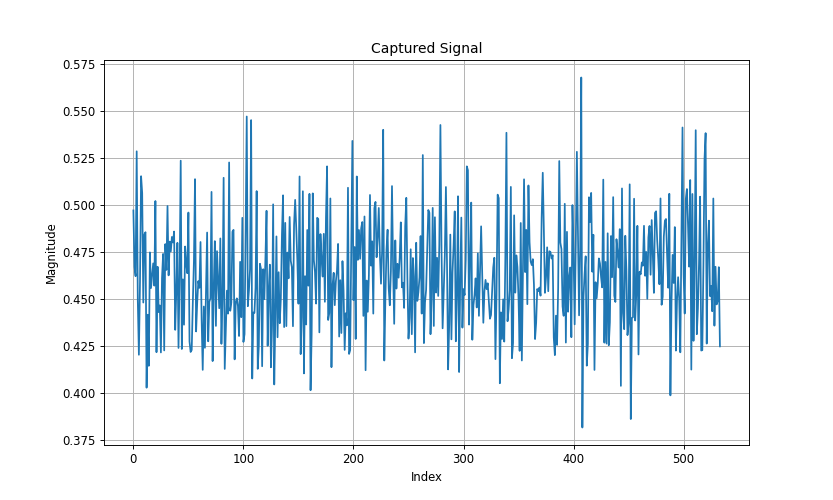

In [43]:
#file last updated 11/16/2025
import numpy as np
import matplotlib.pyplot as plt
import math
data = np.loadtxt("repo/src/output/QPSK_before_demodulation.dat")

complex_data = data[:,0] + 1j * data[:,1]

downsampled = complex_data

N = len(complex_data)

#complex_data = complex_data[N-10:]

# Compute FFT
N = len(complex_data)
print(N)

# Plot
plt.figure(figsize=(10,6))
plt.plot(range(N), abs(complex_data))
plt.xlabel("Index")
plt.ylabel("Magnitude")
plt.title("Captured Signal")
plt.grid(True)
plt.show()



534


<IPython.core.display.Javascript object>


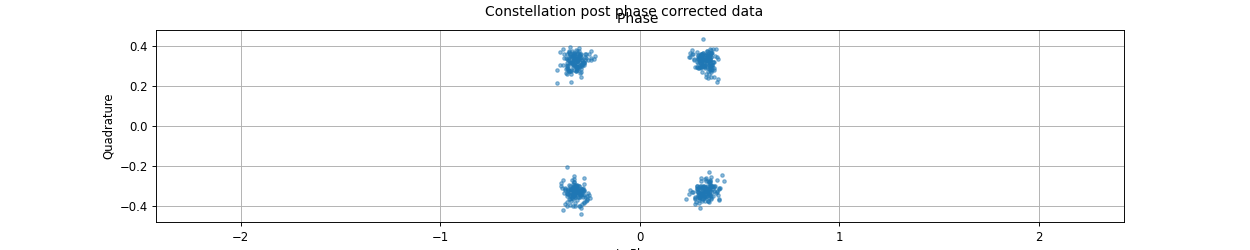

In [46]:
#file last updated 11/16/2025
import numpy as np
import matplotlib.pyplot as plt
import math
data = np.loadtxt("repo/src/output/QPSK_before_demodulation.dat")

complex_data = data[:,0] + 1j * data[:,1]

print(len(complex_data))

downsampled = complex_data


fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=6, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
plt.show()




In [4]:
import numpy as np

#modulated m_sequence
m_seq_init = [-1+0j,
-1+0j,
-1+0j,
-1+0j,
-1+0j,
-1+0j,
1+0j,
-1+0j,
1+0j,
-1+0j,
1+0j,
-1+0j,
-1+0j,
1+0j,
1+0j,
-1+0j,
-1+0j,
1+0j,
-1+0j,
-1+0j,
-1+0j,
1+0j,
-1+0j,
-1+0j,
1+0j,
-1+0j,
1+0j,
1+0j,
-1+0j,
1+0j,
1+0j,
-1+0j,
-1+0j,
-1+0j,
1+0j,
1+0j,
1+0j,
-1+0j,
1+0j,
-1+0j,
-1+0j,
-1+0j,
-1+0j,
1+0j,
1+0j,
-1+0j,
1+0j,
-1+0j,
1+0j,
1+0j,
1+0j,
-1+0j,
-1+0j,
1+0j,
1+0j,
1+0j,
1+0j,
-1+0j,
1+0j,
1+0j,
1+0j,
1+0j,
1+0j]
m_seq_init = np.array(m_seq_init)

# New output for 11/21/2025

<IPython.core.display.Javascript object>


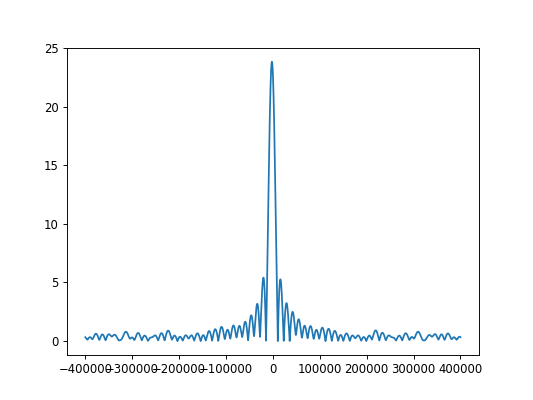

-0.015093412214802277


<IPython.core.display.Javascript object>


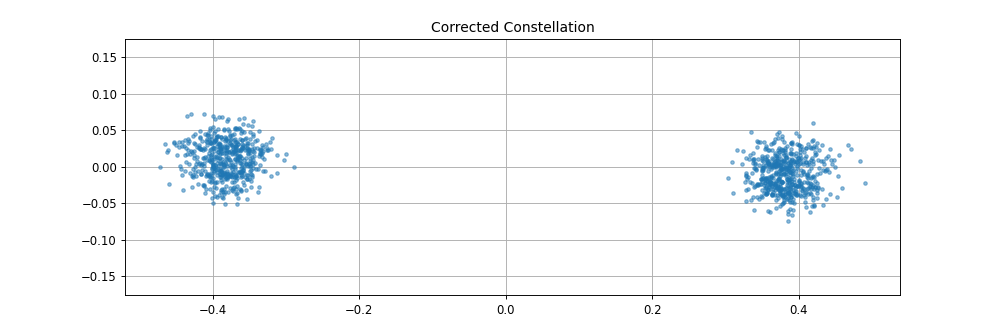

In [23]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("repo/src/output/bob_alice_before_extra_correction.dat")
complex_data = data[:,0] + 1j * data[:,1]

fs = 0.8e6
L = 63

received_pilot = complex_data[:L]
pilot = m_seq_init[:L]

# step 1: form exponential sequence
prod = received_pilot * np.conj(pilot)

# step 2: FFT frequency-offset estimation
Nfft = 32768*2*2*2
prod_zp = np.zeros(Nfft, dtype=complex)
prod_zp[:L] = prod

F = np.fft.fftshift(np.fft.fft(prod_zp))
freqs = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/fs))

plt.plot(freqs,abs(F))

kmax = np.argmax(np.abs(F))
freq_peak_hz = freqs[kmax]
omega_rad_per_sample = 2*np.pi*(freq_peak_hz / fs)

# step 3: estimate constant phase offset after removing frequency slope
n = np.arange(L)
prod_rot = prod * np.exp(-1j * omega_rad_per_sample * n)
theta = np.angle(np.sum(prod_rot))

# step 4: apply correction to entire packet
n_all = np.arange(len(complex_data))
corrected = complex_data * np.exp(-1j * (theta + omega_rad_per_sample * n_all * .91))

print(omega_rad_per_sample * .91)

complex_data = corrected


# -----------------------------------------------   Trying to do a second correction ----------------------------- #
"""fs = 0.8e6
L = 63

received_pilot = complex_data[:L]
pilot = m_seq_init[:L]

# step 1: form exponential sequence
prod = received_pilot * np.conj(pilot)

# step 2: FFT frequency-offset estimation
Nfft = 32768*2*2*2
prod_zp = np.zeros(Nfft, dtype=complex)
prod_zp[:L] = prod


F = np.fft.fftshift(np.fft.fft(prod_zp))
freqs = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/fs))

kmax = np.argmax(np.abs(F))
freq_peak_hz = freqs[kmax]
omega_rad_per_sample = 2*np.pi*(freq_peak_hz / fs)

# step 3: estimate constant phase offset after removing frequency slope
n = np.arange(L)
prod_rot = prod * np.exp(-1j * omega_rad_per_sample * n)
theta = np.angle(np.sum(prod_rot))


# step 4: apply correction to entire packet
n_all = np.arange(len(complex_data))
print(theta)
print(omega_rad_per_sample)
corrected = complex_data * np.exp(-1j * (theta + omega_rad_per_sample * n_all))
"""


# plot constellation
plt.figure(figsize=(12,4))
plt.plot(corrected.real, corrected.imag, '.', alpha=0.5)
plt.grid(True)
plt.axis('equal')
plt.title("Corrected Constellation")
plt.show()


# Experimental stuff

<IPython.core.display.Javascript object>


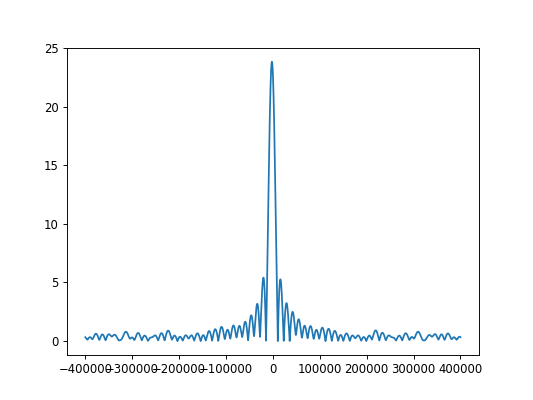

<IPython.core.display.Javascript object>


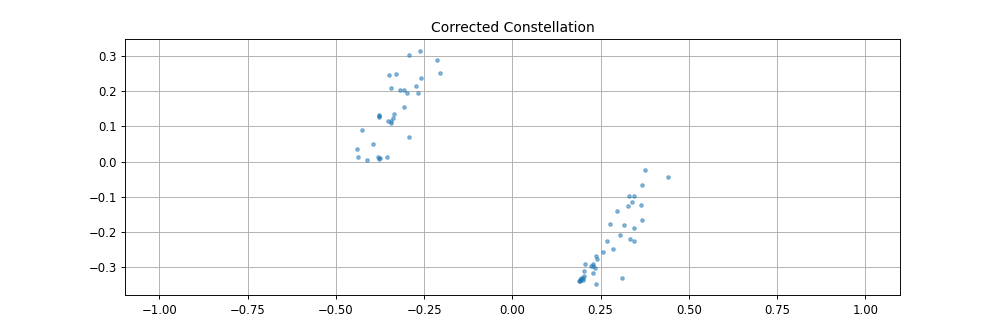

-1.0604335170399122
(0.18813836095400707-0.33606029330990556j)
-0.015149050243427317


<IPython.core.display.Javascript object>


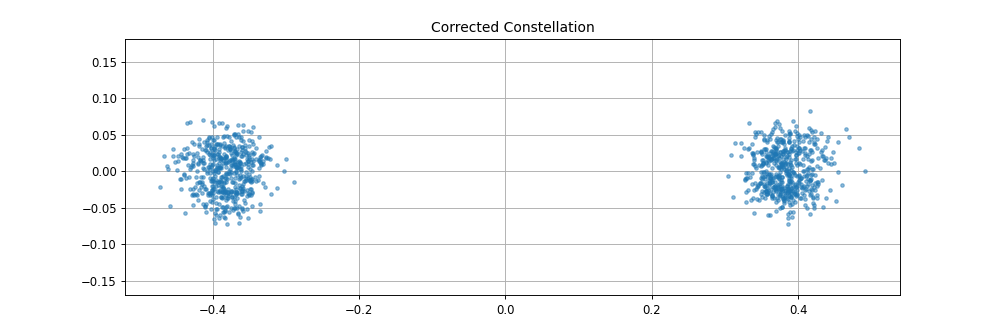

In [32]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("repo/src/output/bob_alice_before_extra_correction.dat")
complex_data = data[:,0] + 1j * data[:,1]

fs = 0.8e6
L = 63

sample_for_slope = 200

received_pilot = complex_data[:L]
pilot = m_seq_init[:L]

# step 1: form exponential sequence
prod = received_pilot * np.conj(pilot)

# step 2: FFT frequency-offset estimation
Nfft = 32768*2*2*2
prod_zp = np.zeros(Nfft, dtype=complex)
prod_zp[:L] = prod

F = np.fft.fftshift(np.fft.fft(prod_zp))
freqs = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/fs))

plt.plot(freqs,abs(F))

kmax = np.argmax(np.abs(F))
freq_peak_hz = freqs[kmax]
omega_rad_per_sample = 2*np.pi*(freq_peak_hz / fs)

# step 3: estimate constant phase offset after removing frequency slope
n = np.arange(L)
prod_rot = prod * np.exp(-1j * omega_rad_per_sample * n)
theta = np.angle(np.sum(prod_rot))


# step 4: apply correction to entire packet
n_all = np.arange(len(complex_data))
#corrected = complex_data * np.exp(-1j * (theta + omega_rad_per_sample * n_all))
corrected = complex_data * np.exp(-1j * (theta))

# plot constellation
plt.figure(figsize=(12,4))
plt.plot(corrected.real[0:70], corrected.imag[0:70], '.', alpha=0.5)
plt.grid(True)
plt.axis('equal')
plt.title("Corrected Constellation")
plt.show()

print(np.angle(corrected[70]))
print(corrected[70])
if(corrected[70].real > 0):
    omega_rad_per_sample = np.angle(corrected[70]) / 70
else:
    omega_rad_per_sample = (np.angle(corrected[70]) - math.pi/2) / 70
print(omega_rad_per_sample)
corrected = corrected * np.exp(omega_rad_per_sample * n_all * -1j)



# plot constellation
plt.figure(figsize=(12,4))
plt.plot(corrected.real, corrected.imag, '.', alpha=0.5)
plt.grid(True)
plt.axis('equal')
plt.title("Corrected Constellation")
plt.show()


In [ ]:
# New output for 11/21/2025


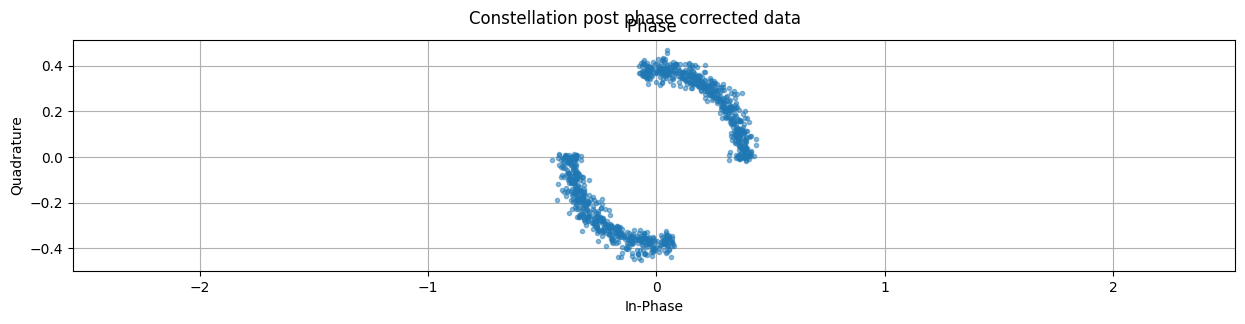

In [6]:
#file last updated 11/16/2025
import numpy as np
import matplotlib.pyplot as plt
import math
data = np.loadtxt("repo/src/output/bob_alice_no_extra_correction.dat")

complex_data = data[:,0] + 1j * data[:,1]

downsampled = complex_data


fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=6, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
#plt.xlim(-1, 1)
#plt.ylim(-1, 1)
plt.show()




# Output from after m-sequence - should be correct!

63
32768
1.6953168732304686
(-3.0183669644385462+24.11449841278031j)


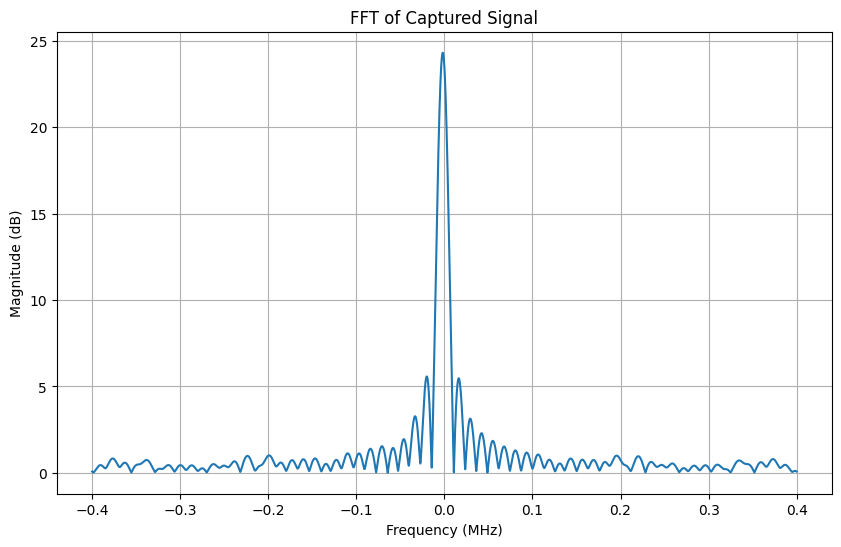

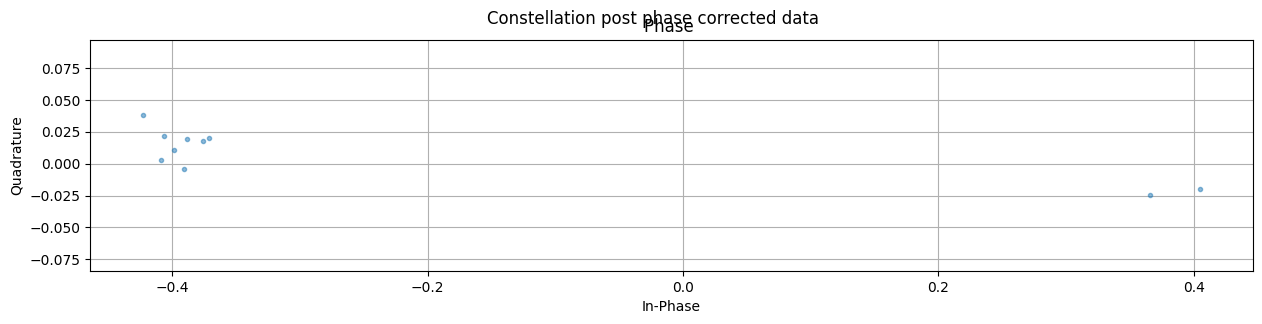

In [46]:
#At this point we have a downsampled packet with known pilot sequence for first 63.
#We just want to perform a fft and find the peak now.
import numpy as np
import matplotlib.pyplot as plt
import math



#file last updated 11/1/2025
data = np.loadtxt("repo/src/output/m_seq_downsamp.dat")

complex_data = data[:,0] + 1j * data[:,1]

fs = (0.8e6)

to_fft_data = complex_data[0:63] * np.conj(m_seq_init)
print(len(to_fft_data))
while (to_fft_data.size != 32768):
    to_fft_data = np.append(to_fft_data, (0+0j))


# Compute FFT
N = len(to_fft_data)
print(N)

fft_data = np.fft.fftshift(np.fft.fft(to_fft_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

kmax = np.argmax(np.abs(F))
peak_val = F[kmax]
freq_peak_hz = freqs[kmax]          # frequency estimate in Hz (centered after fftshift)
omega_rad_per_sec = 2*np.pi*freq_peak_hz
omeg_orig = 2*np.pi*(freq_peak_hz / fs)
omega_rad_per_sample = 2*np.pi*(freq_peak_hz / fs) * 1.25   # radians per sample

print( 1/(omeg_orig/omega_rad_per_sample))


#fft_data = np.fft.fft(to_fft_data)
#freqs = np.fft.fftfreq(N, d=1/fs)


max_value = 0;
max_index = 0
curr_index = 0
for i in fft_data:
    if( abs(i) > max_value ):
        max_value = abs(i)
        max_index = curr_index
    curr_index = curr_index + 1

print(np.angle(fft_data[max_index]))
print(fft_data[max_index])
theta = np.angle(fft_data[max_index])

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6,(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


downsampled = complex_data[0:10] * (math.e**(-1j*theta))


fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=6, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
#plt.xlim(-1, 1)
#plt.ylim(-1, 1)
plt.show()



1.25
FFT peak bin: 16442
freq (Hz) from FFT peak: 1416.0156249999998
omega (rad/sec): 8897.088569736718
omega (rad/sample): 0.013901700890213621


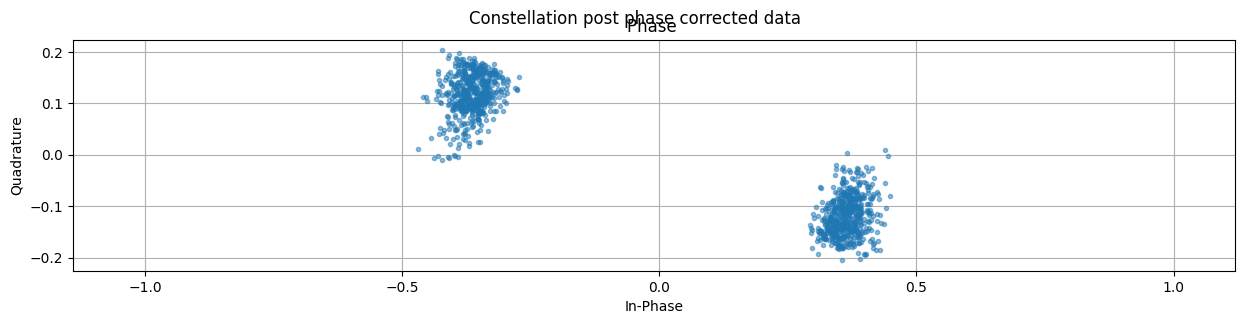

In [87]:
import numpy as np

data = np.loadtxt("repo/src/output/m_seq_downsamp.dat")

complex_data = data[:,0] + 1j * data[:,1]

# assume complex_data (received), m_seq_init (known pilot), fs already defined
L = 63
received_pilot = complex_data[0:L]
pilot = m_seq_init[0:L]

# form product that ideally is complex-exponential exp(j*(omega*n + phi))
prod = received_pilot * np.conj(pilot)

# FFT method
Nfft = 32768
prod_zp = np.zeros(Nfft, dtype=complex)
prod_zp[:L] = prod

F = np.fft.fftshift(np.fft.fft(prod_zp))
freqs = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/fs))   # in Hz

kmax = np.argmax(np.abs(F))
peak_val = F[kmax]
freq_peak_hz = freqs[kmax]          # frequency estimate in Hz (centered after fftshift)
omega_rad_per_sec = 2*np.pi*freq_peak_hz
omeg_orig = 2*np.pi*(freq_peak_hz / fs)
omega_rad_per_sample = 2*np.pi*(freq_peak_hz / fs) * 1.25   # radians per sample

print( 1/(omeg_orig/omega_rad_per_sample))



print("FFT peak bin:", kmax)
print("freq (Hz) from FFT peak:", freq_peak_hz)
print("omega (rad/sec):", omega_rad_per_sec)
print("omega (rad/sample):", omega_rad_per_sample)

#0.01271012652819531


downsampled = complex_data * (math.e**(-1j* (theta + range(0,len(complex_data)) * omega_rad_per_sample) ) )


fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=6, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
#plt.xlim(-1, 1)
#plt.ylim(-1, 1)
plt.show()



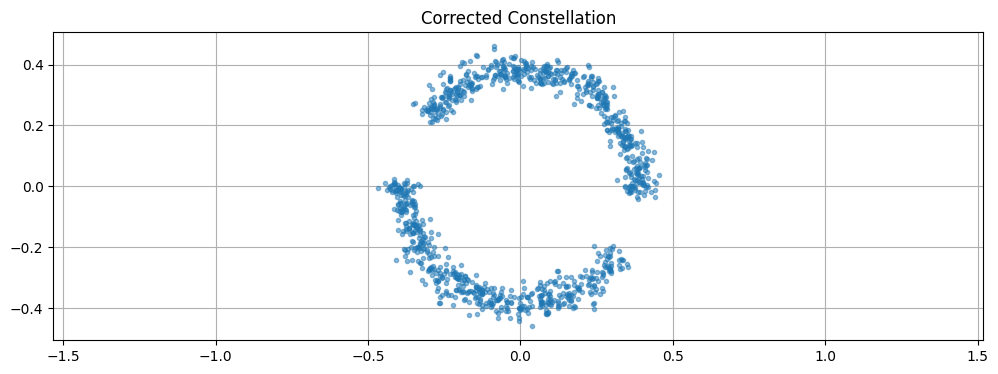

In [68]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("repo/src/output/m_seq_downsamp.dat")
complex_data = data[:,0] + 1j * data[:,1]

fs = 0.8e6
L = 63

received_pilot = complex_data[:L]
pilot = m_seq_init[:L]

# step 1: form exponential sequence
prod = received_pilot * np.conj(pilot)

# step 2: FFT frequency-offset estimation
Nfft = 32768*2*2*2
prod_zp = np.zeros(Nfft, dtype=complex)
prod_zp[:L] = prod

F = np.fft.fftshift(np.fft.fft(prod_zp))
freqs = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/fs))

kmax = np.argmax(np.abs(F))
freq_peak_hz = freqs[kmax]
omega_rad_per_sample = 2*np.pi*(freq_peak_hz / fs)

# step 3: estimate constant phase offset after removing frequency slope
n = np.arange(L)
prod_rot = prod * np.exp(-1j * omega_rad_per_sample * n)
theta = np.angle(np.sum(prod_rot))

# step 4: apply correction to entire packet
n_all = np.arange(len(complex_data))
corrected = complex_data * np.exp(-1j * (theta + omega_rad_per_sample * n_all))

# plot constellation
plt.figure(figsize=(12,4))
plt.plot(corrected.real, corrected.imag, '.', alpha=0.5)
plt.grid(True)
plt.axis('equal')
plt.title("Corrected Constellation")
plt.show()


slope (rad/sample): -0.01463862349766288
freq (Hz): -1863.847431771374
intercept (rad): 1.6970546171595169


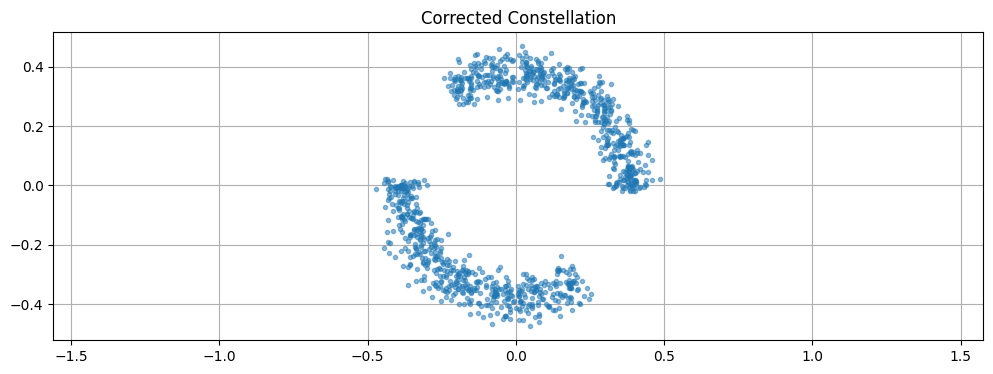

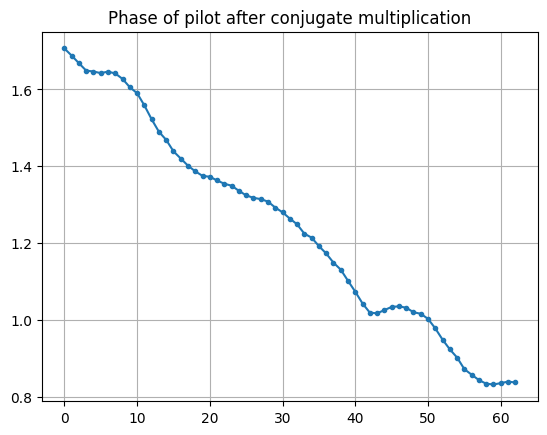

In [49]:
import numpy as np

data = np.loadtxt("repo/src/output/m_seq_downsamp.dat")
complex_data = data[:,0] + 1j * data[:,1]

# inputs you already have:
# complex_data, m_seq_init, fs
L = 63
received_pilot = complex_data[:L]
pilot = m_seq_init[:L]

# product that should be exp(j(omega*n + phi0)) ideally
prod = received_pilot * np.conj(pilot)

# unwrap phase and do linear least-squares (fit: phi[n] = a*n + b)
n = np.arange(L)
phi = np.unwrap(np.angle(prod))

# linear fit for slope a (radians per sample) and intercept b
A = np.vstack([n, np.ones_like(n)]).T
a, b = np.linalg.lstsq(A, phi, rcond=None)[0]   # a = slope in rad/sample, b = intercept

omega_rad_per_sample = a
omega_hz = (omega_rad_per_sample * fs) / (2*np.pi)   # convert to Hz

print("slope (rad/sample):", omega_rad_per_sample)
print("freq (Hz):", omega_hz)
print("intercept (rad):", b)

# Apply correction to whole packet (use np.exp, not math.e)
n_all = np.arange(len(complex_data))
corrected = complex_data * np.exp(-1j*(b + omega_rad_per_sample * n_all))


# plot constellation
plt.figure(figsize=(12,4))
plt.plot(corrected.real, corrected.imag, '.', alpha=0.5)
plt.grid(True)
plt.axis('equal')
plt.title("Corrected Constellation")
plt.show()


plt.plot(np.unwrap(np.angle(received_pilot * np.conj(pilot))), '.-')
plt.title("Phase of pilot after conjugate multiplication")
plt.grid(True)
plt.show()


# Checking pre phase correction

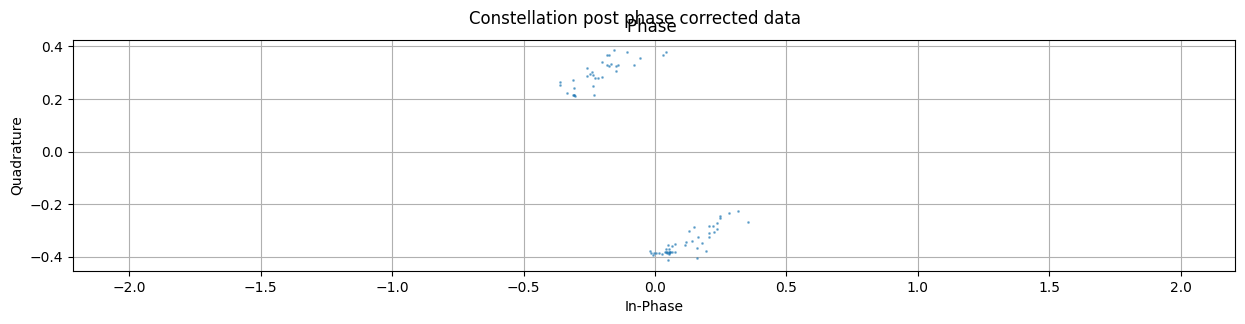

In [17]:
import numpy as np
import matplotlib.pyplot as plt
#file last updated 11/1/2025
data = np.loadtxt("repo/src/output/before_phase_correction.dat")

complex_data = data[:,0] + 1j * data[:,1]

downsampled = complex_data
downsampled = downsampled[0:80]

fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=2, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
#plt.xlim(-1, 1)
#plt.ylim(-1, 1)
plt.show()

# We expect to see points only at -1 and 1 for BPSK

# Checking post phase correction

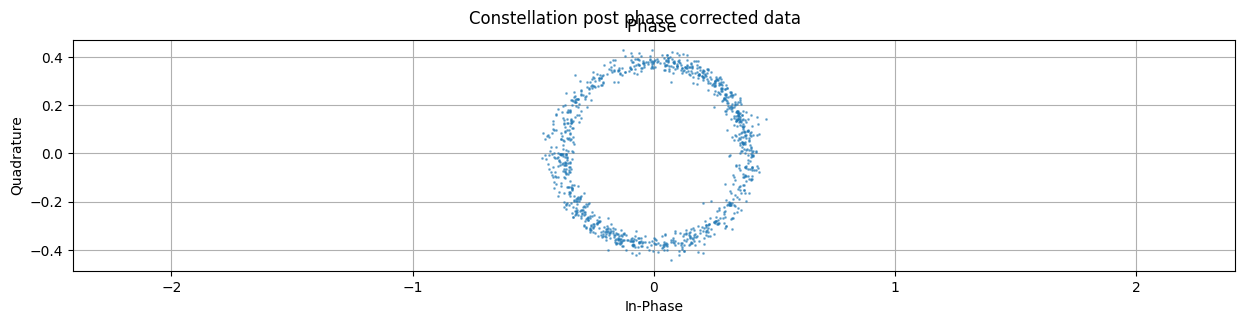

In [81]:
import numpy as np
import matplotlib.pyplot as plt
#file last updated 11/1/2025
data = np.loadtxt("repo/src/output/after_phase_correction.dat")

complex_data = data[:,0] + 1j * data[:,1]

downsampled = complex_data
downsampled = downsampled

fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation post phase corrected data")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=2, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
plt.show()

# We expect to see points only at -1 and 1 for BPSK

# End of valid lab5 analysis

1060
1060


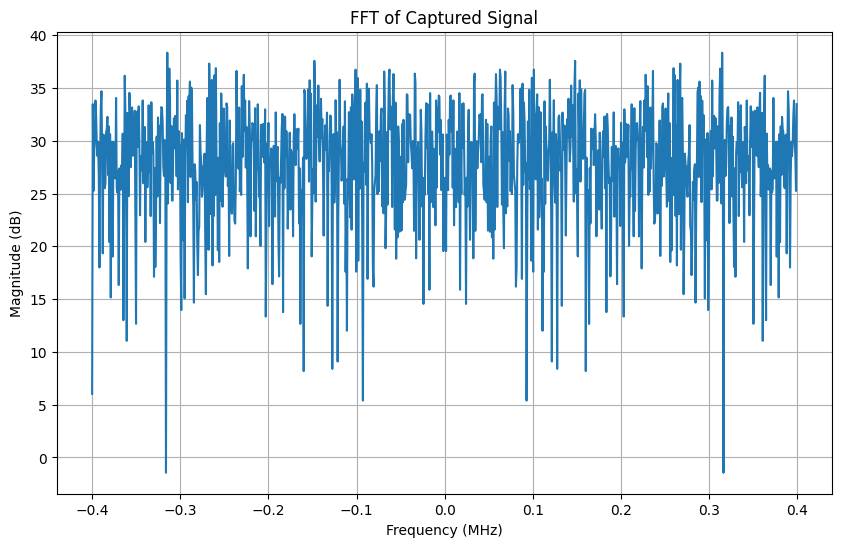

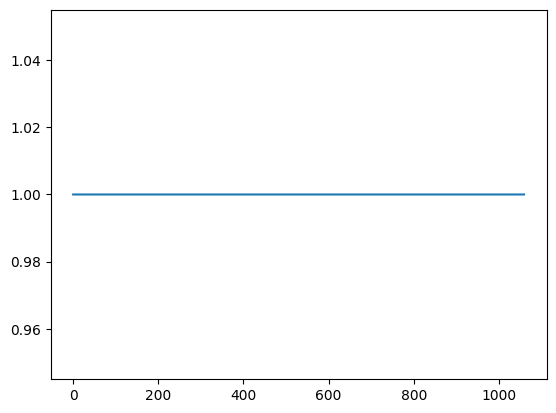

In [2]:
complex_data = data[:,0] + 1j * data[:,1]


fs = (0.8e6)


# Compute FFT
N = len(complex_data)
print(N)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

print(complex_data.size)

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()

plt.plot(range(complex_data.size),abs(complex_data))

In [3]:
# Method 2: Check for contiguous subsequence (most common use case)
def contains_subarray(main, sub):
    if len(sub) > len(main):
        return False
    
    for i in range(len(main) - len(sub) + 1):
        if np.array_equal(main[i:i+len(sub)], sub):
            return True
    return False

# Checking to see if m-sequence is indeed transmitted or not
original_m_seq = [
-1  + 0j,
-1+ 0j,
-1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j,
1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j,
1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j]




is_contiguous = contains_subarray(complex_data, original_m_seq)
print(f"Contains as contiguous subsequence: {is_contiguous}")

Contains as contiguous subsequence: True


# TX chain multi-rate filter impulse response

513


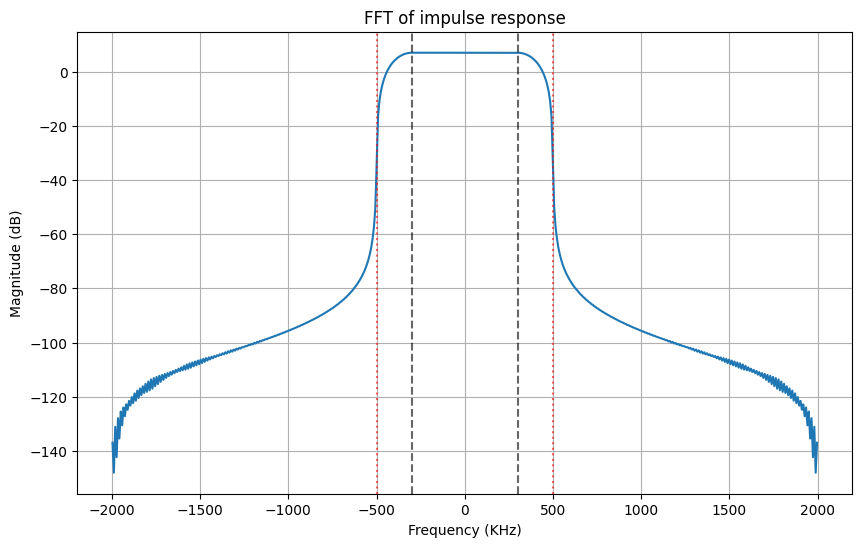

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/impulse_tx_filter_real.dat")

complex_data = data[:,0] + 1j * data[:,1]

impulse_data = complex_data


fs = (4e6)


# Compute FFT
N = len(complex_data)
print(N)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))


# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e3, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (KHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of impulse response")
plt.grid(True)

# theoretical vertical lines (in kHz)
Rs = 800e3
beta = 0.25
f_flat = (1-beta)/2*Rs   # 300kHz
f_roll = (1+beta)/2*Rs   # 500kHz
plt.axvline(+f_flat/1e3, color='k', linestyle='--', alpha=0.6)
plt.axvline(-f_flat/1e3, color='k', linestyle='--', alpha=0.6)
plt.axvline(+f_roll/1e3, color='r', linestyle=':', alpha=0.6)
plt.axvline(-f_roll/1e3, color='r', linestyle=':', alpha=0.6)
plt.show()

# Sanity check that above is a valid RRC filter

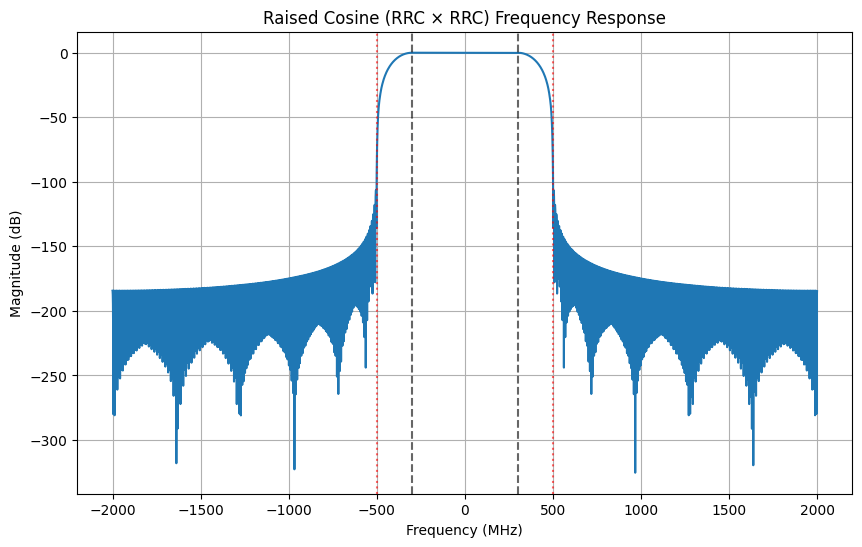

In [5]:
# Compute full raised-cosine (matched filter pair)
rc = np.convolve(complex_data, complex_data)
RC_fft = np.fft.fftshift(np.fft.fft(rc, n=8*len(rc)))
RC_freqs = np.fft.fftshift(np.fft.fftfreq(len(RC_fft), d=1/fs))

plt.figure(figsize=(10,6))
plt.plot(RC_freqs/1e3, 20*np.log10(np.abs(RC_fft)/np.max(np.abs(RC_fft))))
plt.title("Raised Cosine (RRC × RRC) Frequency Response")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)

# theoretical vertical lines (in kHz)
Rs = 800e3
beta = 0.25
f_flat = (1-beta)/2*Rs   # 300kHz
f_roll = (1+beta)/2*Rs   # 500kHz
plt.axvline(+f_flat/1e3, color='k', linestyle='--', alpha=0.6)
plt.axvline(-f_flat/1e3, color='k', linestyle='--', alpha=0.6)
plt.axvline(+f_roll/1e3, color='r', linestyle=':', alpha=0.6)
plt.axvline(-f_roll/1e3, color='r', linestyle=':', alpha=0.6)

plt.show()

# TX chain: Output of match filter

# With no downsampling:

5300


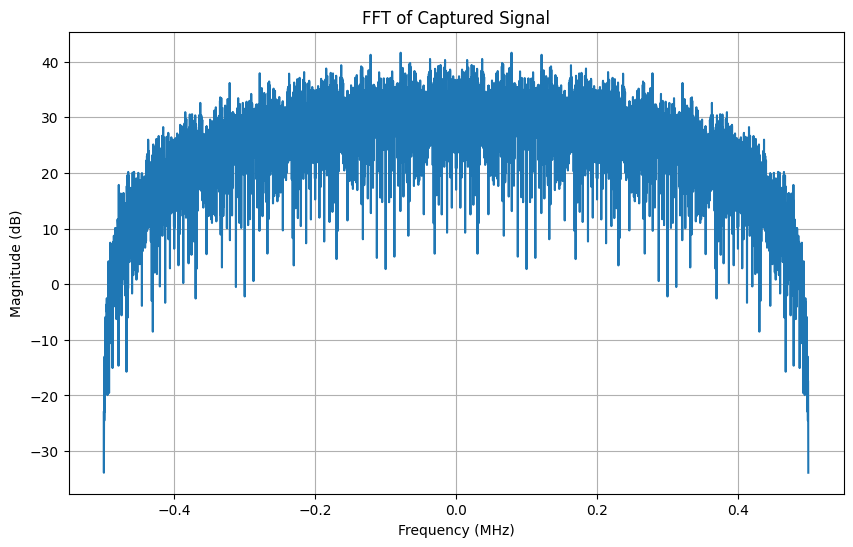

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/match_filter_no_downsample.dat")

complex_data = data[:,0] + 1j * data[:,1]


fs = (1e6)


# Compute FFT
N = len(complex_data)
print(N)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


# with downsampling

1325


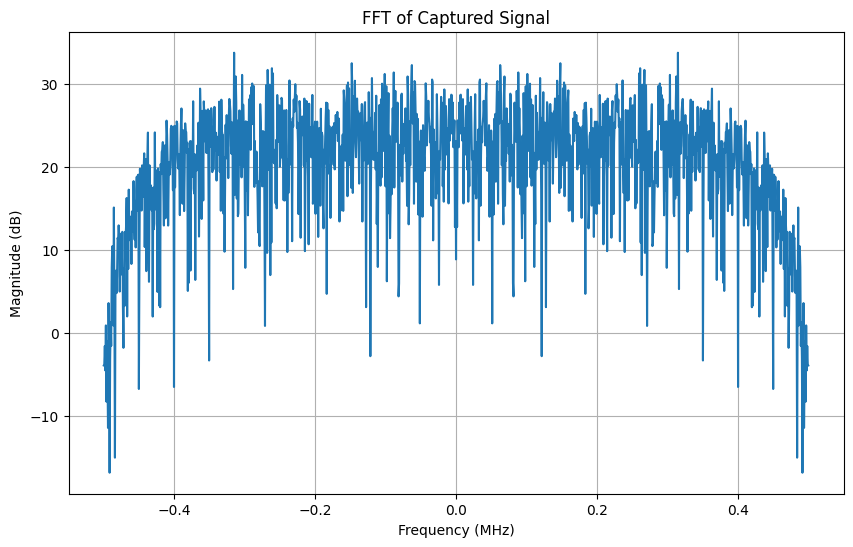

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/match_filter.dat")

complex_data = data[:,0] + 1j * data[:,1]


fs = (1e6)


# Compute FFT
N = len(complex_data)
print(N)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


# Histogram of real values to see if we have operation outside linear range

0.782672


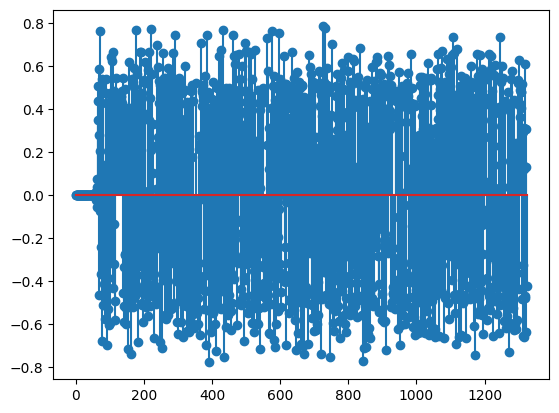

In [230]:
N = len(complex_data)


plt.stem(range(N),complex_data.real)

print(max(abs(complex_data.real)))

1.50216e-07


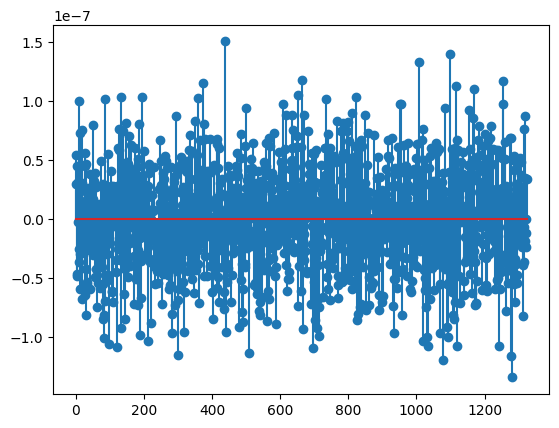

In [231]:
N = len(complex_data)


plt.stem(range(N),complex_data.imag)

print(max(complex_data.imag))

# RX side

# Before match filter

1451


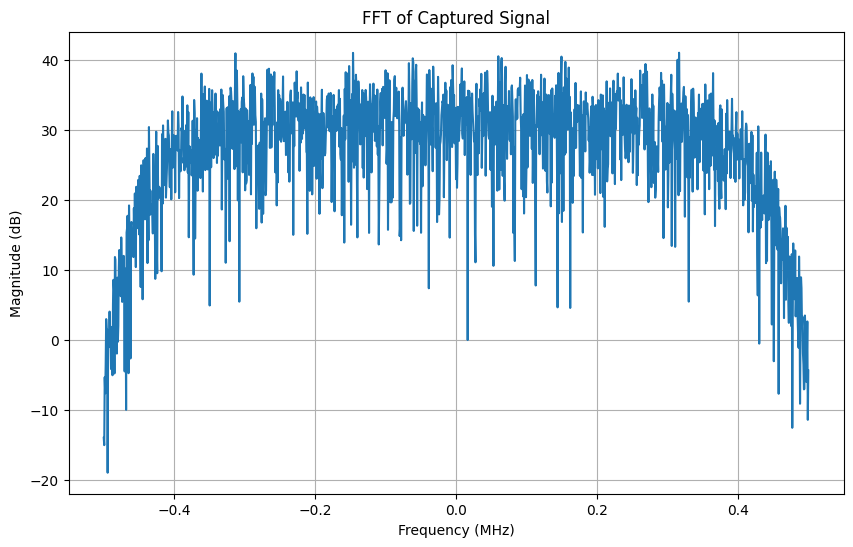

<StemContainer object of 3 artists>

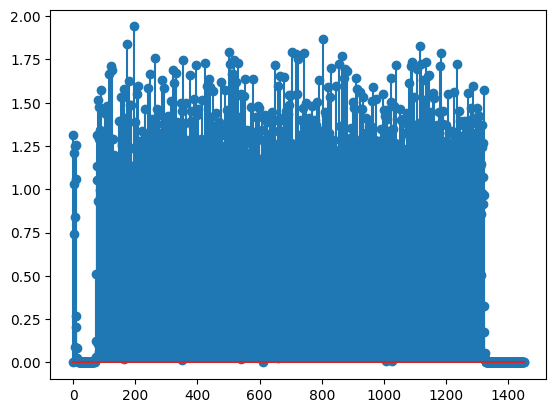

In [232]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/before_rx_match_filter.dat")

complex_data = data[:,0] + 1j * data[:,1]

#complex_data = complex_data[:1325]

fs = (1e6)


# Compute FFT
N = len(complex_data)
print(N)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()

plt.stem(range(N),abs(complex_data))

<IPython.core.display.Javascript object>


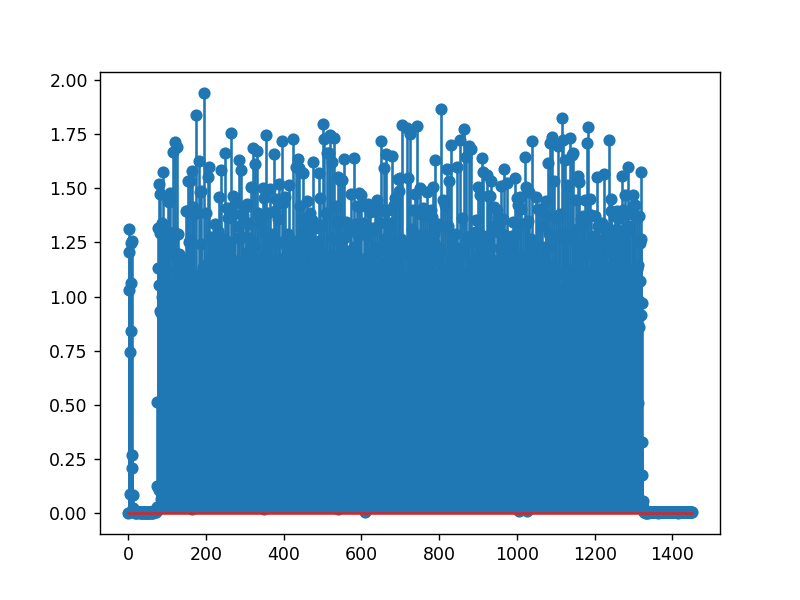

<StemContainer object of 3 artists>

In [233]:
%matplotlib notebook
data = np.loadtxt("repo/src/output/before_rx_match_filter.dat")

complex_data = data[:,0] + 1j * data[:,1]


#start_index = int(np.floor(index_of_max/8))

#length_of_packet_in_this_domain = int(1060 * 5 / 4)
#length_of_packet_in_this_domain = int(1060)


#end_index = start_index + length_of_packet_in_this_domain
#complex_data = complex_data[start_index:  end_index]
#complex_data = complex_data[  0  :  end_index]
plt.stem(range(complex_data.size),abs(complex_data))

In [234]:
%matplotlib inline

# After match filter

11200


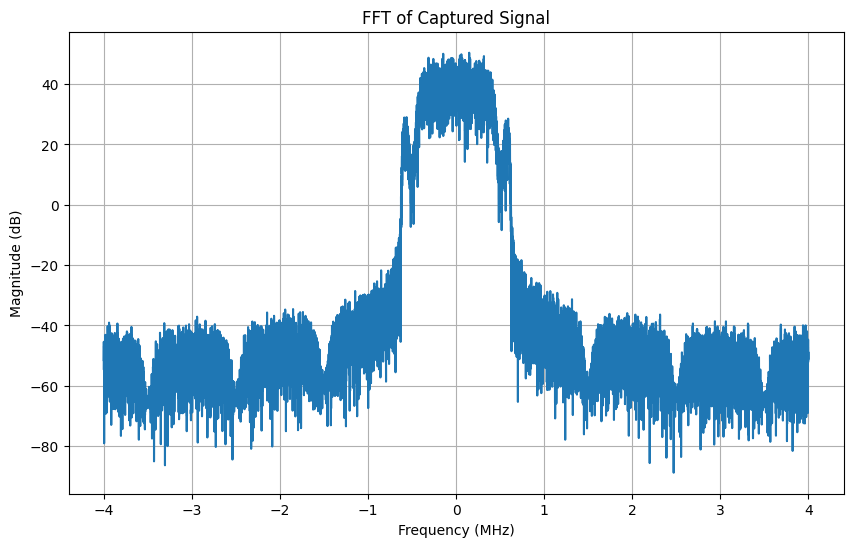

In [247]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/after_rx_match_filter.dat")

complex_data = data[:,0] + 1j * data[:,1]


fs = (8e6)


# Compute FFT
N = len(complex_data)
print(N)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


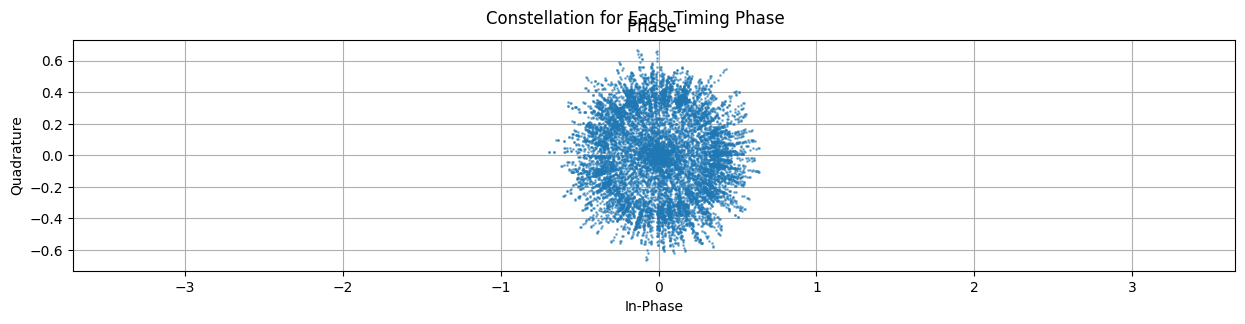

In [248]:

downsampled = complex_data

fig, axes = plt.subplots(1, 1, figsize=(15, 3))
fig.suptitle("Constellation for Each Timing Phase")
# Plot constellation
axes.plot(downsampled.real, downsampled.imag, '.', markersize=2, alpha=0.5)
axes.set_xlabel("In-Phase")
axes.set_ylabel("Quadrature")
axes.set_title(f"Phase ")
axes.grid(True)
axes.axis('equal')
plt.show()

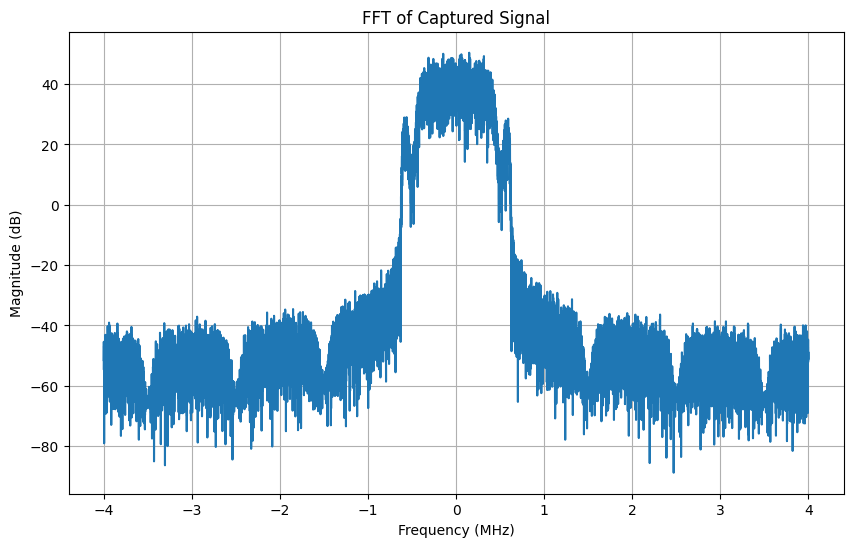

In [249]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/after_rx_match_filter.dat")
complex_data = data[:,0] + 1j * data[:,1]

#fs = ((25e6)/5)*4  # 20 MSPS
#fs = (25e6)  # 25 MSPS
fs = (8e6)


# Compute FFT
N = len(complex_data)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


11200


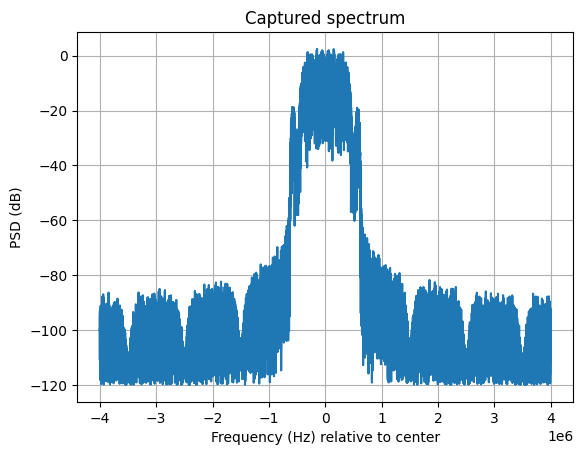

In [250]:
import numpy as np
import matplotlib.pyplot as plt

# x: complex IQ numpy array, Fs = 1e6
Fs = 8e6
x = complex_data  # load your complex samples
print(len(x))

N = 65536                 # choose FFT length
X = np.fft.fftshift(np.fft.fft(x[:N], n=N))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/Fs))

psd = (np.abs(X)**2) / N
psd_db = 10*np.log10(psd + 1e-12)

plt.plot(freqs, psd_db)
plt.xlabel('Frequency (Hz) relative to center')
plt.ylabel('PSD (dB)')
plt.title('Captured spectrum')
plt.grid(True)
plt.show()

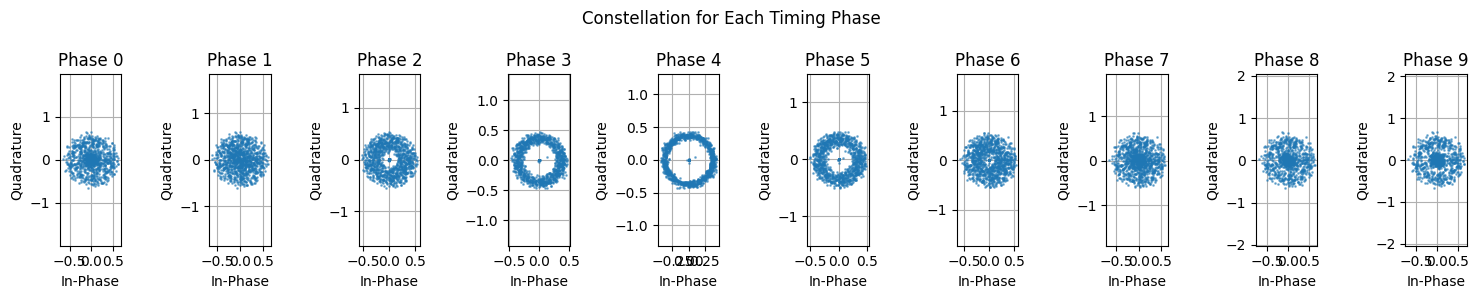

In [251]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/after_rx_match_filter.dat")
complex_data = data[:,0] + 1j * data[:,1]


# Parameters
upsampling_factor = 10

# Create 5 subplots for each timing phase
fig, axes = plt.subplots(1, upsampling_factor, figsize=(15, 3))
fig.suptitle("Constellation for Each Timing Phase")

for phase in range(upsampling_factor):
    # Downsample by upsampling_factor starting at 'phase' offset
    downsampled = complex_data[phase::upsampling_factor]
    
    # Plot constellation
    axes[phase].plot(downsampled.real, downsampled.imag, '.', markersize=2, alpha=0.5)
    axes[phase].set_xlabel("In-Phase")
    axes[phase].set_ylabel("Quadrature")
    axes[phase].set_title(f"Phase {phase}")
    axes[phase].grid(True)
    axes[phase].axis('equal')
    
plt.tight_layout()
plt.show()

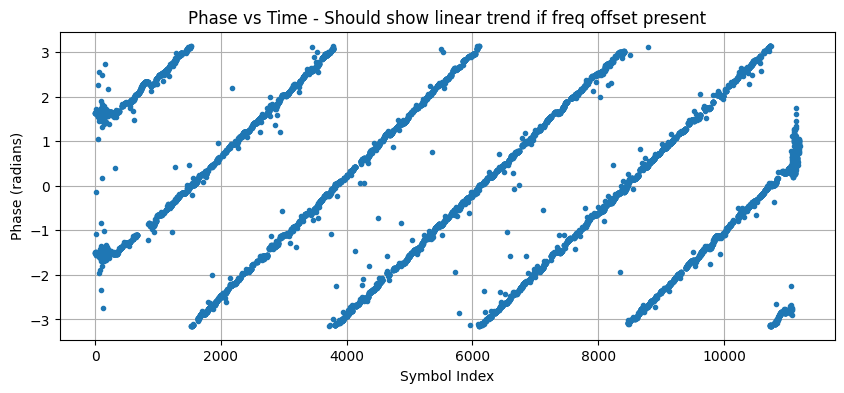

In [252]:
phase_idx = 1
downsampled = complex_data[phase_idx::upsampling_factor]
downsampled = complex_data

# Plot phase over time
phase_angles = np.angle(downsampled)
plt.figure(figsize=(10,4))
plt.plot(phase_angles, '.')
plt.xlabel("Symbol Index")
plt.ylabel("Phase (radians)")
plt.title("Phase vs Time - Should show linear trend if freq offset present")
plt.grid(True)
plt.show()

In [253]:
data = np.loadtxt("repo/src/output/after_rx_match_filter.dat")
complex_data = data[:,0] + 1j * data[:,1]

original_m_seq = [
-1  + 0j,
-1+ 0j,
-1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j,
1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j,
1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j,
-1+ 0j,
1+ 0j,
-1+ 0j,
-1+ 0j,
1+ 0j,
1+ 0j]


#original_m_seq = np.array(original_m_seq) * -1

11200


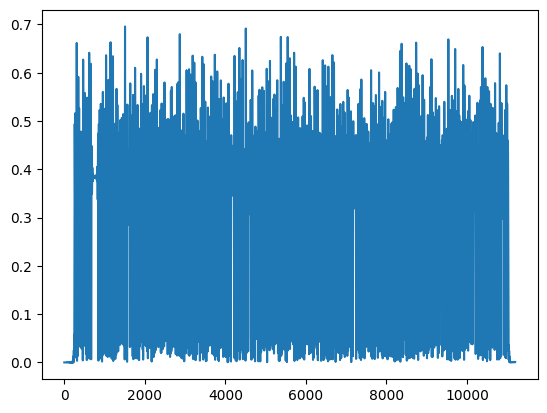

In [254]:
#%matplotlib notebook
plt.plot(range(complex_data.size),abs(complex_data))
print(complex_data.size)

<StemContainer object of 3 artists>

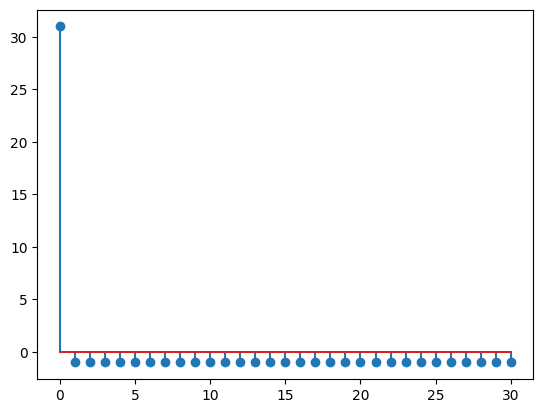

In [255]:
import numpy as np

def periodic_autocorr(x):
    N = len(x)
    corr = np.zeros(N, dtype=complex)
    for k in range(N):
        corr[k] = np.sum(x * np.roll(x, k).conj())
    return corr

# Example usage
corr_periodic = periodic_autocorr(original_m_seq)
corr_periodic = np.real(corr_periodic)

plt.stem(range(corr_periodic.size),corr_periodic)


10889
384


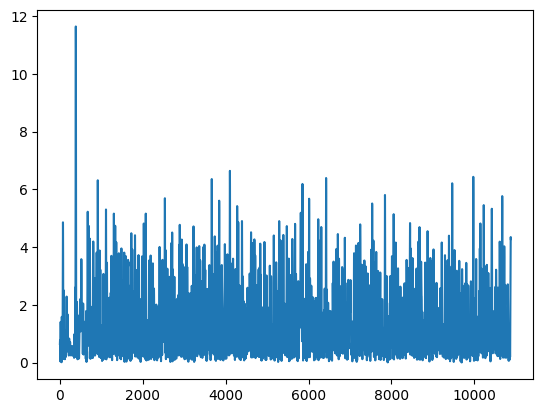

In [259]:
to_plot = np.array([])


rows = 10    # Total upsampling rate
columns = 31 # M-sequence length
dmx = np.zeros((rows,columns), dtype=complex)
sample_delta = rows
shift_end = complex_data.size - (rows*columns+1)

print(shift_end)

shift_end = int(np.floor(shift_end/sample_delta))
for shift in range(0,shift_end):
    for i in range(rows):
        for j in range(columns):
            dmx[i][j] = complex_data[i+j*10 + (sample_delta * shift) ]
    #At this point we have our desired dmx matrix so we need to do our weird multiplication
    for row in range(rows):
        to_plot = np.append(to_plot,    np.sum(dmx[row] * np.conjugate(original_m_seq))       )

#plt.xlim([0,5000])        
index_of_max = np.argmax(abs(to_plot))
print(index_of_max)
plt.plot(range(to_plot.size), abs(to_plot) )

# Demodulation

In [257]:
# You will likely need to run the payload definition below!

#Index of max is the start of my M_sequence
#I think at least?

#demod = np.zeros(1016, dtype=int)
demod = np.zeros(1616, dtype=int)

# Start with the last symbol of the M-sequence as reference

last_symbol = complex_data[index_of_max + 30*10]  # Last M-seq symbol
error_total = 0

payload_bits_to_check = 1000

# Demodulate packet number (16 bits) + payload (1000 bits)
for i in range(payload_bits_to_check + 16): #accounting f 
    symbol = complex_data[index_of_max + (i+31)*10]  # First data symbol is at position 31
    diff = symbol * np.conj(last_symbol)
    demod[i] = 1 if diff.real < 0 else 0
    last_symbol = symbol

print(demod)

# Compare payload only (skip first 16 bits which are packet number)
for i in range(payload_bits_to_check):  # 1000 payload bits
    if demod[i+16] != payload[i]:
        print(f"Error at payload bit {i} (demod bit {i+16})")
        error_total += 1

print("Total errors:", error_total)

[0 0 0 ... 0 0 0]
Total errors: 0


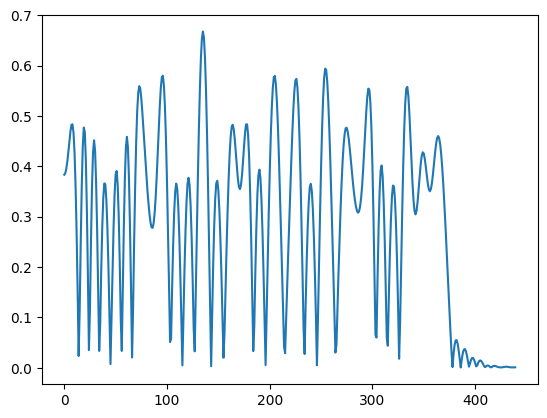

In [246]:
index_of_interest = index_of_max + (956+31)*10
end_of_interest = index_of_max + (1000+31)*10
time_domain_error = complex_data[index_of_interest:end_of_interest]
plt.plot(range(time_domain_error.size),abs(time_domain_error))

In [183]:
# Test if sampling 1 sample earlier/later helps
for offset in [-6,-5,-4,-3,-2,-1, 0, 1,2,3,4,5,6]:
    demod_test = np.zeros(1016, dtype=int)
    last_symbol = complex_data[index_of_max + 30*10 + offset]
    errors = 0
    for i in range(1016):
        symbol = complex_data[index_of_max + (i+31)*10 + offset]
        diff = symbol * np.conj(last_symbol)
        demod_test[i] = 1 if diff.real < 0 else 0
        last_symbol = symbol
    
    errors = np.sum(demod_test[16:] != payload[:1000])
    print(f"Offset {offset}: {errors} errors")

Offset -6: 454 errors
Offset -5: 298 errors
Offset -4: 84 errors
Offset -3: 28 errors
Offset -2: 31 errors
Offset -1: 30 errors
Offset 0: 31 errors
Offset 1: 31 errors
Offset 2: 31 errors
Offset 3: 106 errors
Offset 4: 312 errors
Offset 5: 465 errors
Offset 6: 501 errors


# Writing my own demodulation code

In [145]:
import cmath
import math
data = np.loadtxt("repo/src/output/after_rx_match_filter.dat")
complex_data = data[:,0] + 1j * data[:,1]
demod = np.zeros(1016, dtype=int)

# Start with the last symbol of the M-sequence as reference

last_symbol = complex_data[index_of_max + 30*10]
error_total = 0
last_symbol = np.conj(last_symbol)

payload_bits_to_check = 1000

# Demodulate packet number (16 bits) + payload (1000 bits)
for i in range(payload_bits_to_check + 16): #accounting f 
    symbol = complex_data[index_of_max + (i+31)*10]  # First data symbol is at position 31
    angle_diff = cmath.phase(symbol) - cmath.phase(last_symbol)
    if(abs(angle_diff) > math.pi/2):
        demod[i] = 1
    else:
        demod[i] = 0
    last_symbol = symbol

print(demod)

# Compare payload only (skip first 16 bits which are packet number)
for i in range(payload_bits_to_check):  # 1000 payload bits
    if demod[i+16] != payload[i]:
        print(f"Error at payload bit {i} (demod bit {i+16})")
        error_total += 1

print("Total errors:", error_total)

[0 0 0 ... 0 0 0]
Error at payload bit 759 (demod bit 775)
Error at payload bit 943 (demod bit 959)
Error at payload bit 945 (demod bit 961)
Error at payload bit 947 (demod bit 963)
Error at payload bit 951 (demod bit 967)
Error at payload bit 952 (demod bit 968)
Error at payload bit 953 (demod bit 969)
Error at payload bit 955 (demod bit 971)
Error at payload bit 956 (demod bit 972)
Error at payload bit 958 (demod bit 974)
Error at payload bit 959 (demod bit 975)
Error at payload bit 962 (demod bit 978)
Error at payload bit 964 (demod bit 980)
Error at payload bit 965 (demod bit 981)
Error at payload bit 967 (demod bit 983)
Error at payload bit 971 (demod bit 987)
Error at payload bit 972 (demod bit 988)
Error at payload bit 973 (demod bit 989)
Error at payload bit 978 (demod bit 994)
Error at payload bit 980 (demod bit 996)
Error at payload bit 984 (demod bit 1000)
Error at payload bit 986 (demod bit 1002)
Error at payload bit 987 (demod bit 1003)
Error at payload bit 990 (demod bit 

In [139]:
import cmath
print(cmath.phase(1+2j))

1.1071487177940904


# Lab 3

0.600249
8.48964e-08


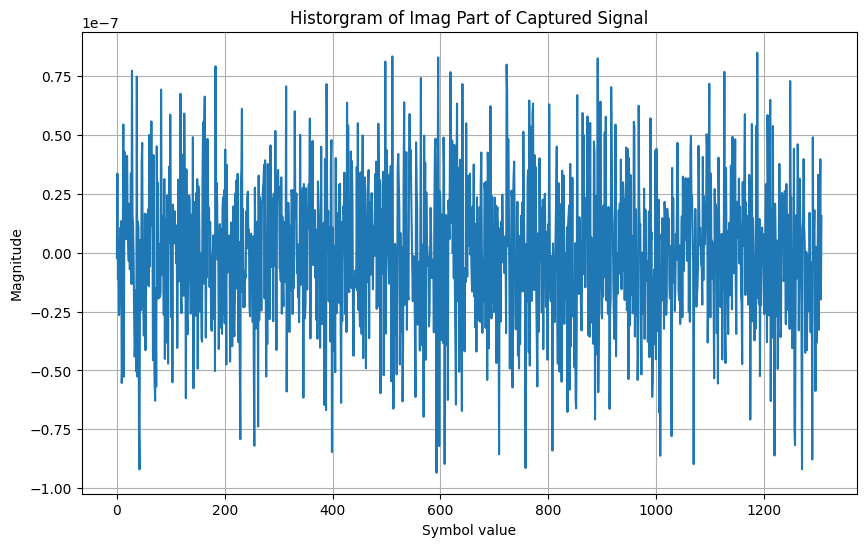

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/histo.dat")
complex_data = data[:,0] + 1j * data[:,1]


# Compute FFT
N = len(complex_data.imag)

print(max(complex_data.real))
print(max(complex_data.imag))
# Plot
plt.figure(figsize=(10,6))
plt.plot(range(0,N),complex_data.imag)
#plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Symbol value")
plt.ylabel("Magnitude")
plt.title("Historgram of Imag Part of Captured Signal")
plt.grid(True)
plt.show()


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/ignore.dat")
complex_data = data[:,0] + 1j * data[:,1]

#fs = ((25e6)/5)*4  # 20 MSPS
#fs = (25e6)  # 25 MSPS
fs = (5e6)


# Compute FFT
N = len(complex_data)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


FileNotFoundError: repo/src/ignore.dat not found.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x: complex IQ numpy array, Fs = 1e6
Fs = 5e6
x = complex_data  # load your complex samples
print(len(x))

N = 65536                 # choose FFT length
X = np.fft.fftshift(np.fft.fft(x[:N], n=N))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/Fs))

psd = (np.abs(X)**2) / N
psd_db = 10*np.log10(psd + 1e-12)

plt.plot(freqs, psd_db)
plt.xlabel('Frequency (Hz) relative to center')
plt.ylabel('PSD (dB)')
plt.title('Captured spectrum')
plt.grid(True)
plt.show()

# Before match filter, RX side

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/ignore.dat")
complex_data = data[:,0] + 1j * data[:,1]

#fs = ((25e6)/5)*4  # 20 MSPS
#fs = (25e6)  # 25 MSPS
fs = (1e6)


# Compute FFT
N = len(complex_data)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


# RRC responde on RX side

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load text file: two columns (real, imag)
data = np.loadtxt("repo/src/output/response.dat")
complex_data = data[:,0] + 1j * data[:,1]

#fs = ((25e6)/5)*4  # 20 MSPS
#fs = (25e6)  # 25 MSPS
fs = (8e6)


# Compute FFT
N = len(complex_data)
fft_data = np.fft.fftshift(np.fft.fft(complex_data))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

# Plot
plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, 20*np.log10(np.abs(fft_data)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Captured Signal")
plt.grid(True)
plt.show()


# Payload data

In [1]:
payload = [1,
0,
0,
0,
1,
1,
0,
0,
0,
1,
1,
0,
1,
0,
1,
0,
0,
1,
1,
0,
1,
1,
1,
1,
1,
0,
0,
0,
1,
1,
0,
1,
1,
1,
1,
1,
0,
1,
1,
1,
0,
0,
1,
1,
1,
0,
0,
0,
1,
1,
1,
0,
0,
1,
0,
0,
0,
0,
0,
1,
0,
0,
1,
1,
1,
1,
0,
1,
1,
1,
1,
1,
0,
0,
0,
0,
0,
0,
1,
0,
1,
1,
0,
0,
0,
1,
0,
1,
0,
0,
1,
0,
1,
1,
1,
0,
0,
0,
1,
0,
0,
1,
1,
1,
1,
1,
0,
0,
0,
1,
1,
1,
1,
0,
0,
0,
0,
0,
1,
1,
1,
1,
0,
1,
1,
0,
0,
1,
0,
0,
1,
1,
1,
0,
0,
1,
0,
1,
0,
0,
1,
0,
1,
1,
1,
0,
1,
0,
0,
1,
1,
0,
0,
0,
0,
1,
1,
0,
0,
0,
1,
0,
0,
1,
0,
1,
1,
0,
0,
0,
0,
0,
1,
1,
0,
0,
0,
0,
1,
1,
0,
1,
0,
1,
1,
0,
0,
0,
0,
1,
0,
0,
1,
1,
1,
1,
0,
1,
0,
1,
1,
1,
0,
1,
1,
1,
1,
0,
0,
1,
0,
0,
1,
1,
1,
0,
0,
1,
1,
0,
1,
1,
0,
0,
1,
0,
1,
1,
1,
0,
1,
0,
1,
1,
0,
1,
1,
1,
0,
1,
1,
0,
1,
0,
0,
1,
0,
0,
0,
1,
0,
0,
1,
0,
0,
1,
1,
1,
0,
1,
1,
0,
1,
1,
0,
0,
1,
1,
1,
1,
1,
1,
0,
0,
0,
0,
1,
0,
0,
1,
0,
1,
1,
1,
0,
1,
0,
1,
1,
0,
1,
1,
1,
0,
1,
0,
1,
1,
1,
1,
0,
0,
0,
1,
0,
1,
1,
0,
0,
0,
1,
0,
1,
0,
0,
0,
1,
1,
0,
0,
0,
1,
1,
0,
1,
0,
0,
0,
0,
1,
0,
0,
0,
0,
0,
0,
0,
1,
0,
1,
1,
1,
1,
1,
0,
0,
0,
1,
1,
1,
0,
1,
1,
1,
0,
1,
0,
1,
0,
1,
1,
1,
1,
1,
1,
1,
0,
1,
1,
1,
0,
0,
1,
0,
0,
0,
0,
0,
0,
1,
1,
1,
0,
1,
0,
0,
0,
0,
0,
1,
0,
0,
0,
1,
0,
0,
1,
1,
0,
1,
0,
1,
1,
1,
1,
1,
1,
0,
1,
0,
1,
0,
1,
1,
0,
0,
1,
1,
0,
1,
0,
0,
1,
0,
1,
1,
0,
1,
1,
0,
0,
0,
0,
1,
1,
0,
1,
0,
1,
1,
0,
0,
0,
1,
0,
1,
1,
1,
1,
1,
1,
1,
1,
0,
1,
1,
0,
0,
0,
1,
0,
1,
1,
0,
0,
1,
0,
1,
1,
1,
0,
1,
1,
1,
1,
0,
1,
1,
0,
0,
0,
1,
0,
0,
1,
1,
0,
1,
1,
1,
0,
1,
0,
0,
1,
1,
0,
0,
0,
0,
1,
0,
0,
0,
1,
0,
0,
0,
1,
1,
0,
1,
0,
1,
1,
0,
0,
0,
0,
1,
0,
0,
1,
1,
0,
1,
1,
1,
0,
0,
1,
0,
0,
1,
1,
1,
1,
0,
0,
0,
1,
0,
1,
1,
0,
1,
0,
0,
0,
0,
1,
0,
0,
1,
0,
0,
1,
0,
1,
1,
1,
1,
1,
0,
1,
1,
0,
1,
0,
0,
1,
0,
1,
1,
1,
1,
0,
0,
0,
1,
1,
0,
1,
1,
1,
0,
1,
0,
0,
1,
0,
0,
0,
0,
1,
1,
0,
0,
1,
1,
1,
0,
0,
1,
0,
0,
0,
1,
0,
1,
0,
0,
1,
1,
1,
1,
1,
1,
1,
0,
1,
0,
1,
1,
0,
0,
0,
0,
1,
1,
0,
0,
1,
0,
0,
0,
0,
0,
0,
0,
1,
0,
0,
0,
0,
1,
0,
1,
0,
1,
0,
1,
1,
0,
1,
0,
0,
1,
0,
0,
0,
1,
1,
0,
0,
1,
0,
0,
0,
0,
0,
1,
0,
0,
0,
0,
1,
0,
1,
1,
1,
0,
0,
1,
1,
1,
1,
0,
0,
0,
1,
1,
0,
0,
1,
1,
1,
0,
1,
0,
1,
0,
0,
0,
1,
0,
1,
0,
0,
1,
0,
1,
0,
1,
1,
1,
1,
1,
1,
1,
0,
0,
1,
0,
0,
1,
1,
1,
0,
0,
1,
1,
0,
0,
1,
1,
1,
1,
1,
0,
0,
0,
1,
0,
1,
0,
0,
1,
1,
0,
1,
1,
1,
0,
1,
1,
1,
0,
0,
0,
0,
0,
1,
1,
1,
0,
1,
0,
0,
0,
1,
1,
0,
1,
1,
0,
1,
1,
0,
1,
0,
1,
1,
0,
1,
0,
1,
1,
1,
0,
1,
1,
1,
0,
1,
0,
1,
1,
0,
0,
1,
0,
0,
0,
1,
0,
1,
1,
1,
0,
0,
0,
0,
1,
0,
0,
1,
0,
0,
1,
1,
0,
0,
1,
0,
1,
1,
0,
1,
1,
1,
0,
0,
0,
1,
0,
0,
1,
0,
1,
0,
0,
0,
1,
0,
1,
0,
1,
0,
0,
0,
0,
0,
0,
1,
0,
0,
0,
1,
0,
1,
0,
0,
1,
0,
0,
1,
1,
1,
0,
1,
1,
1,
0,
0,
1,
1,
1,
0,
0,
0,
0,
0,
1,
1,
1,
0,
1,
1,
0,
0,
1,
1,
1,
0,
0,
0,
1,
1,
0,
0,
0,
0,
0,
1,
1,
0,
1,
1,
0,
1,
0,
0,
0,
1,
0,
0,
1,
1,
0,
0,
0,
1,
1,
0,
0,
1,
0,
0,
1,
1,
0,
0,
0,
0,
0,
0,
1,
1,
1,
0,
0,
1,
1,
1,
1,
1,
1,
0,
0,
0,
1,
1,
1,
0,
1,
1,
0,
0,
1,
1,
0,
1,
0,
1,
1,
0,
1,
0,
0,
0,
1,
1,
1,
0,
0,
0,
0,
1,
0,
1,
0,
0,
0,
1,
0,
1,
1,
0,
0,
1,
0,
0,
0,
0,
1,
1,
0,
1,
1]

In [3]:
import numpy as np
data = np.loadtxt("symbols.dat")

In [4]:
data == payload

C:\Users\Quintin\AppData\Local\Temp\ipykernel_10228\3961459579.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  data == payload


False

In [28]:
data = np.loadtxt("symbols.dat")
wow = True
print(data.size)
data = data[60:]
print(data.size)
print(len(payload))
for i in range(1000):
    print(str(int(data[i])) +" :\t" + str(payload[i]))

1060
1000
1000
1 :	1
1 :	0
1 :	0
1 :	0
-1 :	1
1 :	1
1 :	0
1 :	0
1 :	0
-1 :	1
1 :	1
1 :	0
-1 :	1
-1 :	0
1 :	1
1 :	0
1 :	0
-1 :	1
1 :	1
1 :	0
-1 :	1
1 :	1
-1 :	1
1 :	1
-1 :	1
-1 :	0
-1 :	0
-1 :	0
1 :	1
-1 :	1
-1 :	0
1 :	1
-1 :	1
1 :	1
-1 :	1
1 :	1
1 :	0
-1 :	1
1 :	1
-1 :	1
-1 :	0
-1 :	0
1 :	1
-1 :	1
1 :	1
1 :	0
1 :	0
1 :	0
-1 :	1
1 :	1
-1 :	1
-1 :	0
-1 :	0
1 :	1
1 :	0
1 :	0
1 :	0
1 :	0
1 :	0
-1 :	1
-1 :	0
-1 :	0
1 :	1
-1 :	1
1 :	1
-1 :	1
-1 :	0
1 :	1
-1 :	1
1 :	1
-1 :	1
1 :	1
1 :	0
1 :	0
1 :	0
1 :	0
1 :	0
1 :	0
-1 :	1
-1 :	0
1 :	1
-1 :	1
-1 :	0
-1 :	0
-1 :	0
1 :	1
1 :	0
-1 :	1
-1 :	0
-1 :	0
1 :	1
1 :	0
-1 :	1
1 :	1
-1 :	1
-1 :	0
-1 :	0
-1 :	0
1 :	1
1 :	0
1 :	0
-1 :	1
1 :	1
-1 :	1
1 :	1
-1 :	1
-1 :	0
-1 :	0
-1 :	0
1 :	1
-1 :	1
1 :	1
-1 :	1
-1 :	0
-1 :	0
-1 :	0
-1 :	0
-1 :	0
1 :	1
-1 :	1
1 :	1
-1 :	1
-1 :	0
1 :	1
-1 :	1
-1 :	0
-1 :	0
1 :	1
1 :	0
1 :	0
-1 :	1
1 :	1
-1 :	1
-1 :	0
-1 :	0
1 :	1
1 :	0
-1 :	1
-1 :	0
-1 :	0
1 :	1
1 :	0
-1 :	1
1 :	1
-1 :	1
-1 :	0
1 :	1
1 :	0
1 :	0
-1 :	1
1 :	1
1 :

# Some lab5 stuff

<StemContainer object of 3 artists>

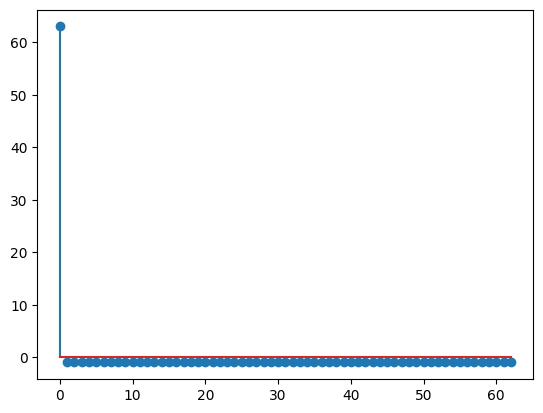

In [13]:
#Checking validity of new m-sequence:
import numpy as np

new_m_seq = np.array([1,1,1,1,1,1,0,1,0,1,0,1,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,0,1,0,0,1,1,1,0,0,0,1,0,1,1,1,1,0,0,1,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0])

def periodic_autocorr(x):
    N = len(x)
    corr = np.zeros(N, dtype=complex)
    for k in range(N):
        corr[k] = np.sum(x * np.roll(x, k).conj())
    return corr

x_pm = 2*new_m_seq - 1

# Example usage
corr_periodic = periodic_autocorr(x_pm)
corr_periodic = np.real(corr_periodic)

plt.stem(range(corr_periodic.size),corr_periodic)

